# Aula 005 – Árvores de Decisão (ID3 com sklearn)

**Disciplina:** 3404 – Aprendizagem de Máquina  
**Dataset:** Pesquisa sobre gripe – carregado diretamente do Google Sheets  
**Objetivo:** Aplicar o algoritmo ID3 (critério de entropia/ganho de informação) ao conjunto de dados coletado, reproduzindo os passos da metodologia estudada em aula.


## 1. Importação das Bibliotecas

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')


## 2. Carregamento dos Dados

In [16]:
URL = 'https://docs.google.com/spreadsheets/d/1g1aQ61vijh6uHJuc8sijeBEMsoIQ2a5yLwUK04Wptlg/export?format=csv'
df_raw = pd.read_csv(URL)
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (186, 11)


,Carimbo de data/hora,Você ficou gripado no ano passado ?,Você tomou vacina da gripe no ano passado?,"Você frequentou no ano passado, semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)",Você viajou no ano passado mais de 100 km de distância?,"Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?",Quantas horas você dormiu em média por noite no ano passado?,Você praticou atividade física no ano passado?,Você se alimentou de forma balanceada no ano passado?,"Em média, quantas vezes você lavou as mãos por dia no ano passado?","Na sua percepção, o seu nível de estresse no ano passado foi:"
0,24/03/2026 15:01:35,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,24/03/2026 15:04:20,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,24/03/2026 15:04:20,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,24/03/2026 15:04:37,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,24/03/2026 15:05:27,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


## 3. Pré-processamento

In [17]:
# Renomear colunas para nomes curtos
colunas = {
    df_raw.columns[0]:  'timestamp',
    df_raw.columns[1]:  'gripado',
    df_raw.columns[2]:  'vacina',
    df_raw.columns[3]:  'ambientes_cheios',
    df_raw.columns[4]:  'viajou',
    df_raw.columns[5]:  'alergia',
    df_raw.columns[6]:  'horas_sono',
    df_raw.columns[7]:  'atividade_fisica',
    df_raw.columns[8]:  'alimentacao',
    df_raw.columns[9]:  'lavou_maos',
    df_raw.columns[10]: 'nivel_estresse'
}
df = df_raw.rename(columns=colunas).drop(columns=['timestamp'])

# Remover linhas com valores ausentes
df = df.dropna()
print('Registros após limpeza:', len(df))
print('\nDistribuição da classe alvo (gripado):')
print(df['gripado'].value_counts())


Registros após limpeza: 185

Distribuição da classe alvo (gripado):
gripado
Sim    108
Não     77
Name: count, dtype: int64


In [18]:
# Codificar variáveis categóricas com LabelEncoder
df_enc = df.copy()
encoders = {}
for col in df_enc.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    encoders[col] = le

print('Mapeamento da variável alvo (gripado):')
for i, cls in enumerate(encoders['gripado'].classes_):
    print(f'  {i} -> {cls}')

df_enc.head()


Mapeamento da variável alvo (gripado):
  0 -> Não
  1 -> Sim


,gripado,vacina,ambientes_cheios,viajou,alergia,horas_sono,atividade_fisica,alimentacao,lavou_maos,nivel_estresse
0,1,1,1,2,1,0,1,2,1,4
1,1,1,1,0,2,1,0,0,3,2
2,1,0,1,2,3,2,1,2,2,2
3,1,0,0,0,0,2,1,2,0,1
4,1,1,1,1,1,1,0,2,2,3


## 4. Cálculo Manual do Ganho de Informação (Entropia)

In [19]:
def entropia(series):
    """Calcula a entropia de Shannon de uma Series categórica."""
    proporcoes = series.value_counts(normalize=True)
    return -np.sum(proporcoes * np.log2(proporcoes + 1e-9))

def ganho_informacao(df, atributo, alvo='gripado'):
    """Calcula o ganho de informação de um atributo em relação ao alvo."""
    H_total = entropia(df[alvo])
    valores = df[atributo].unique()
    H_cond = 0
    for v in valores:
        subset = df[df[atributo] == v][alvo]
        peso = len(subset) / len(df)
        H_cond += peso * entropia(subset)
    return H_total - H_cond

# Calcular ganho de informação para cada atributo
atributos = [c for c in df.columns if c != 'gripado']
ganhos = {attr: round(ganho_informacao(df, attr), 4) for attr in atributos}
ganhos_df = pd.DataFrame(list(ganhos.items()), columns=['Atributo', 'Ganho de Informação'])
ganhos_df = ganhos_df.sort_values('Ganho de Informação', ascending=False).reset_index(drop=True)

H_total = round(entropia(df['gripado']), 4)
print(f'Entropia total do conjunto (gripado): {H_total:.4f} bits')
print()
print('Ganho de Informação por Atributo:')
print(ganhos_df.to_string(index=False))


Entropia total do conjunto (gripado): 0.9796 bits

Ganho de Informação por Atributo:
        Atributo  Ganho de Informação
          viajou               0.0332
  nivel_estresse               0.0234
      horas_sono               0.0195
      lavou_maos               0.0172
         alergia               0.0102
ambientes_cheios               0.0069
atividade_fisica               0.0060
     alimentacao               0.0053
          vacina               0.0011


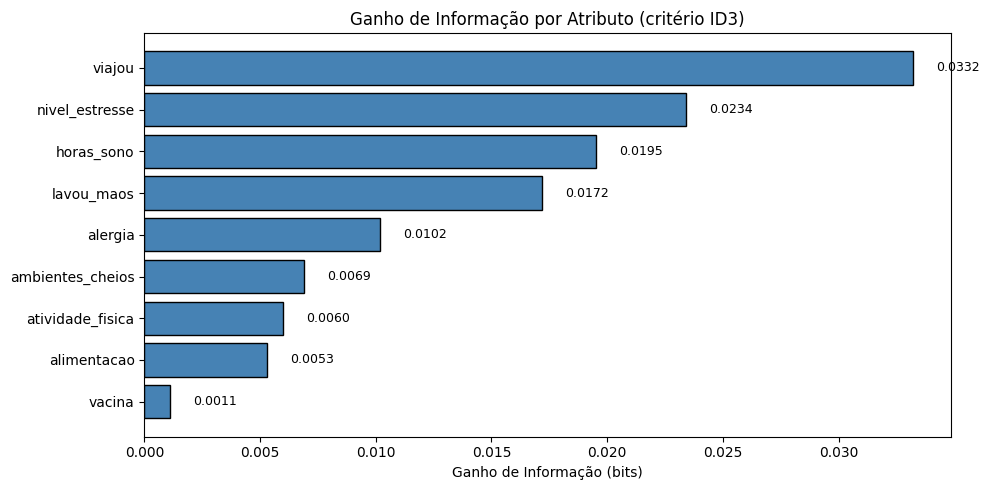

Atributo raiz (maior ganho): viajou


In [20]:
# Visualizar ganhos de informação
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ganhos_df['Atributo'][::-1], ganhos_df['Ganho de Informação'][::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Ganho de Informação (bits)')
ax.set_title('Ganho de Informação por Atributo (critério ID3)')
for bar, val in zip(bars, ganhos_df['Ganho de Informação'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()

plt.show()
print('Atributo raiz (maior ganho):', ganhos_df.iloc[0]['Atributo'])


## 5. Treinamento da Árvore de Decisão (ID3 via sklearn)

In [21]:
X = df_enc.drop(columns=['gripado'])
y = df_enc['gripado']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print(f'Proporção da classe no treino: {y_train.value_counts(normalize=True).to_dict()}')


Treino: 129 amostras | Teste: 56 amostras
Proporção da classe no treino: {1: 0.5813953488372093, 0: 0.4186046511627907}


In [22]:
# criterion='entropy' corresponde ao critério ID3 (ganho de informação)
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

print('Árvore treinada!')
print(f'Profundidade máxima da árvore: {clf.get_depth()}')
print(f'Número de folhas: {clf.get_n_leaves()}')


Árvore treinada!
Profundidade máxima da árvore: 12
Número de folhas: 58


## 6. Visualização da Árvore de Decisão

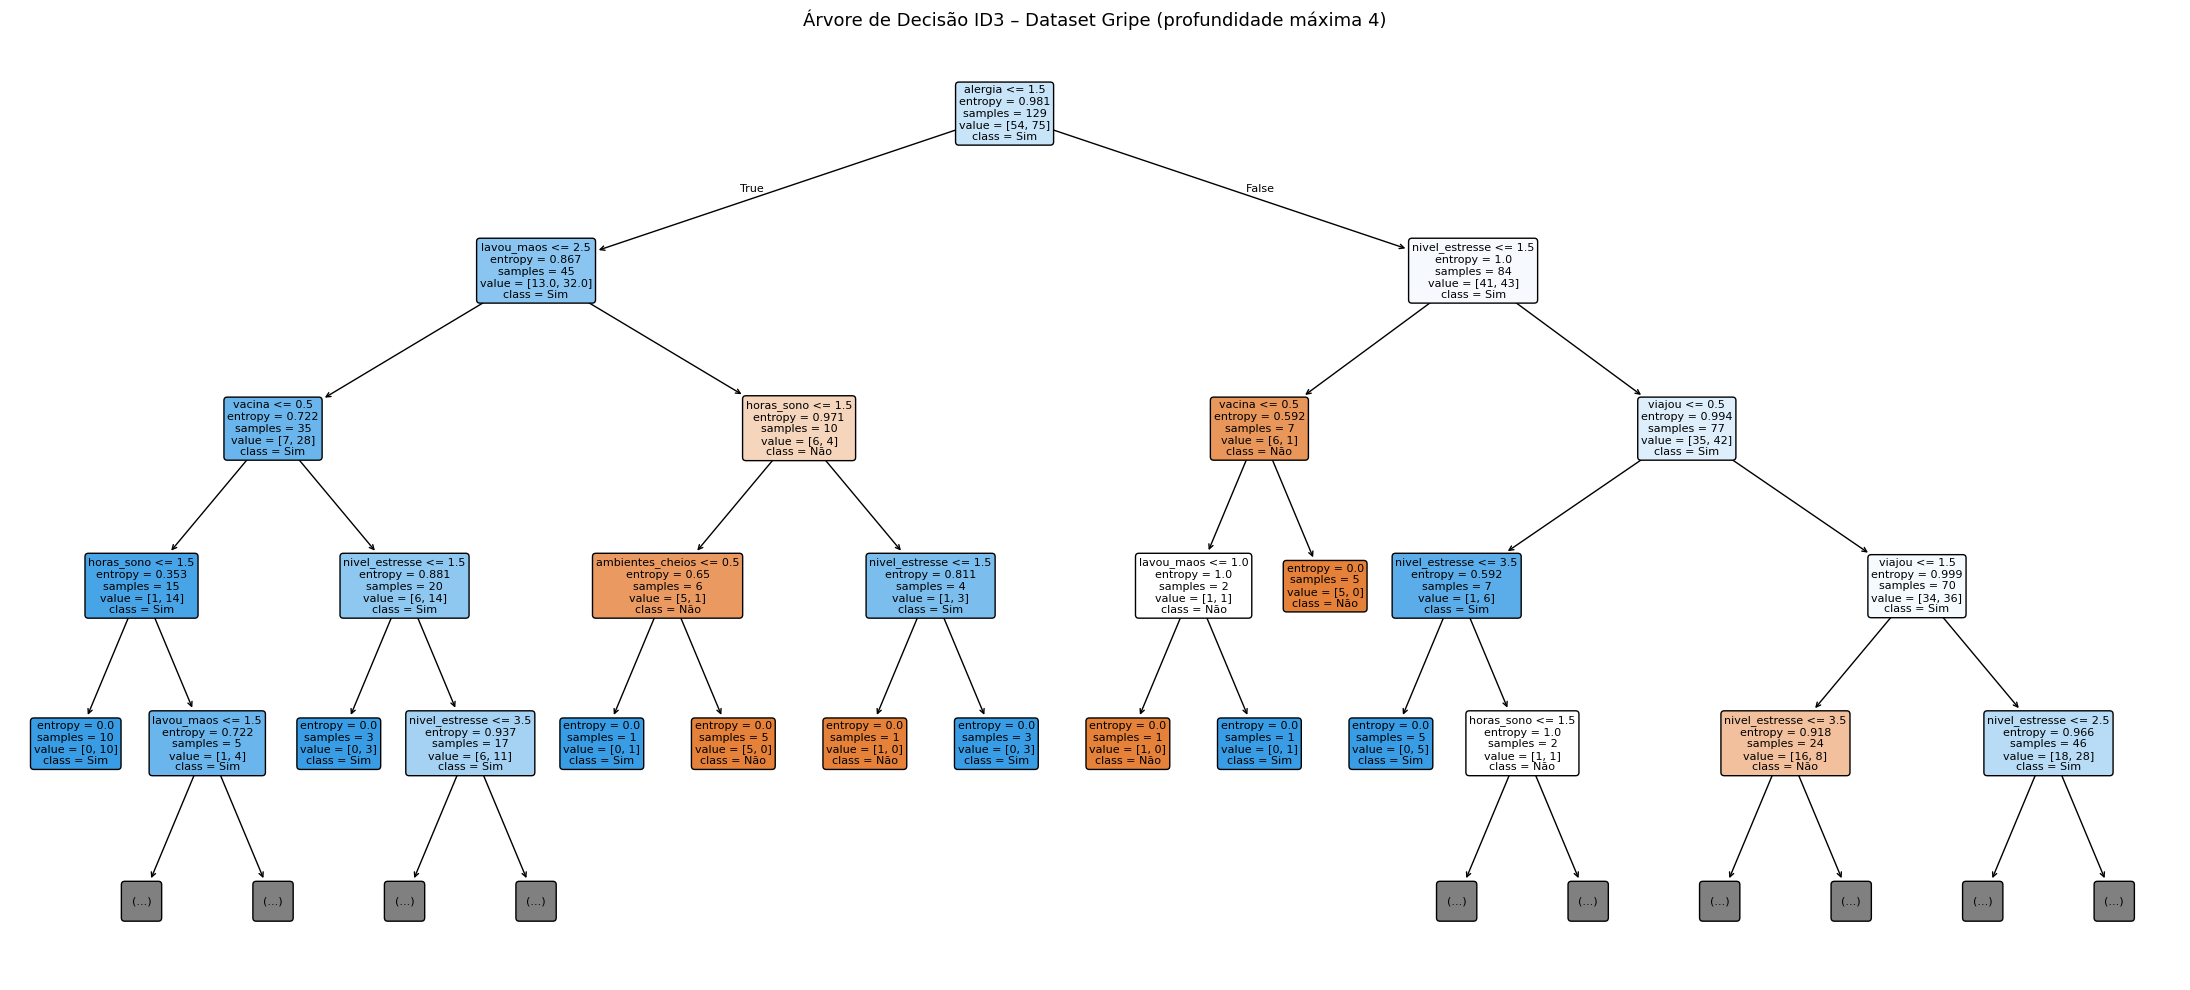

In [23]:
nomes_classes = list(encoders['gripado'].classes_)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=nomes_classes,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    max_depth=4  # limitar profundidade para legibilidade
)
plt.title('Árvore de Decisão ID3 – Dataset Gripe (profundidade máxima 4)', fontsize=13)
plt.tight_layout()
plt.show()


In [24]:
# Representação textual da árvore (até profundidade 3)
regras = export_text(clf, feature_names=X.columns.tolist(), max_depth=3)
print(regras)


|--- alergia <= 1.50
|   |--- lavou_maos <= 2.50
|   |   |--- vacina <= 0.50
|   |   |   |--- horas_sono <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- horas_sono >  1.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- vacina >  0.50
|   |   |   |--- nivel_estresse <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- nivel_estresse >  1.50
|   |   |   |   |--- truncated branch of depth 5
|   |--- lavou_maos >  2.50
|   |   |--- horas_sono <= 1.50
|   |   |   |--- ambientes_cheios <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- ambientes_cheios >  0.50
|   |   |   |   |--- class: 0
|   |   |--- horas_sono >  1.50
|   |   |   |--- nivel_estresse <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- nivel_estresse >  1.50
|   |   |   |   |--- class: 1
|--- alergia >  1.50
|   |--- nivel_estresse <= 1.50
|   |   |--- vacina <= 0.50
|   |   |   |--- lavou_maos <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- lavou_maos >  1.00
|   |   |   |   |--- class

## 7. Avaliação do Modelo

In [25]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Acurácia no conjunto de teste: {acc:.2%}')
print()
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=nomes_classes))


Acurácia no conjunto de teste: 46.43%

Relatório de Classificação:
              precision    recall  f1-score   support

         Não       0.38      0.48      0.42        23
         Sim       0.56      0.45      0.50        33

    accuracy                           0.46        56
   macro avg       0.47      0.47      0.46        56
weighted avg       0.48      0.46      0.47        56



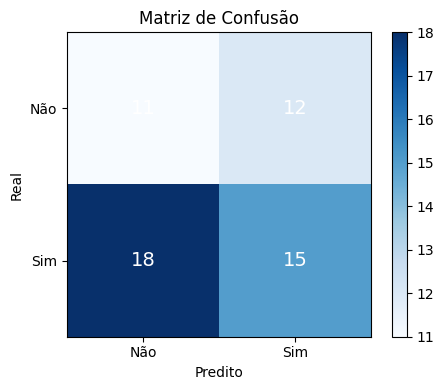

In [26]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(nomes_classes); ax.set_yticklabels(nomes_classes)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 8. Importância dos Atributos

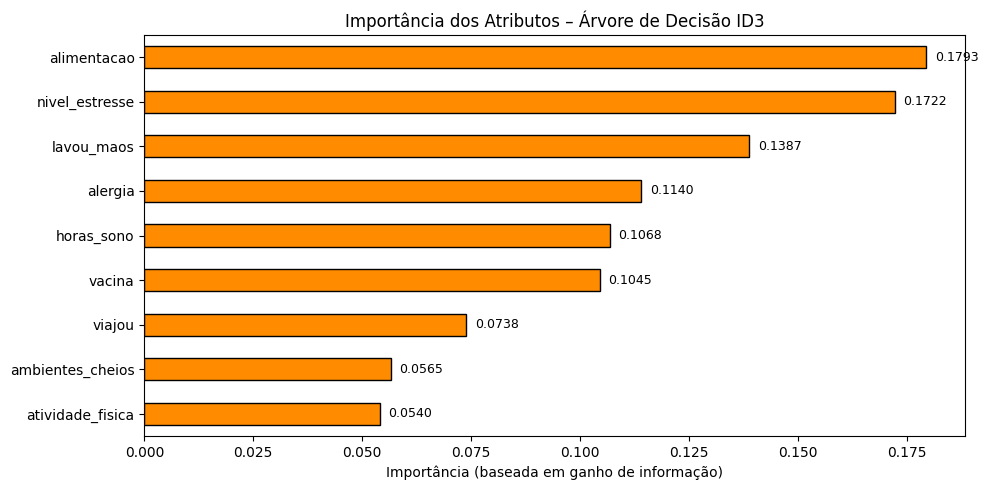

Top 3 atributos mais importantes:
alimentacao       0.179349
nivel_estresse    0.172174
lavou_maos        0.138734


In [27]:
importancias = pd.Series(clf.feature_importances_, index=X.columns)\
                 .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importancias[::-1].plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_xlabel('Importância (baseada em ganho de informação)')
ax.set_title('Importância dos Atributos – Árvore de Decisão ID3')
for i, v in enumerate(importancias[::-1]):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 3 atributos mais importantes:')
print(importancias.head(3).to_string())


## 9. Experimento: Controlando a Profundidade da Árvore

Para evitar **overfitting**, podemos limitar a profundidade máxima da árvore (`max_depth`). Abaixo comparamos a acurácia de treino e teste para diferentes profundidades.


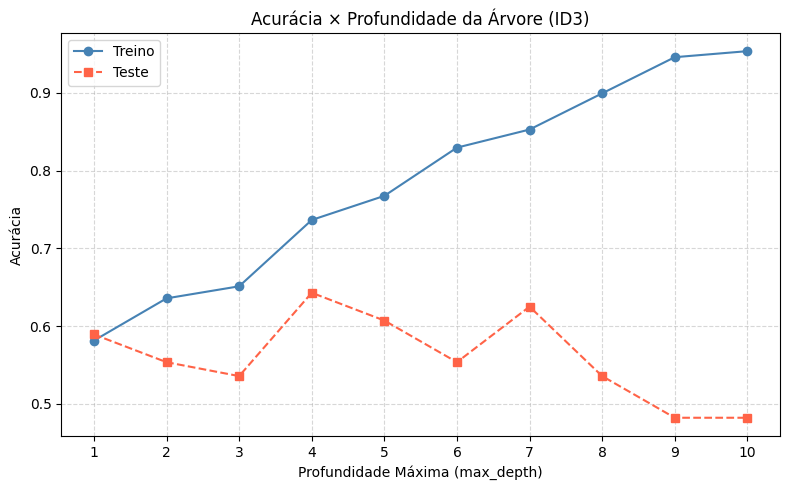

Melhor profundidade para o conjunto de teste: 4 (acurácia = 64.29%)


In [28]:
profundidades = range(1, 11)
acc_treino, acc_teste = [], []

for d in profundidades:
    m = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    acc_treino.append(accuracy_score(y_train, m.predict(X_train)))
    acc_teste.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(profundidades, acc_treino, 'o-', label='Treino', color='steelblue')
ax.plot(profundidades, acc_teste,  's--', label='Teste',  color='tomato')
ax.set_xlabel('Profundidade Máxima (max_depth)')
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia × Profundidade da Árvore (ID3)')
ax.legend()
ax.set_xticks(list(profundidades))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

melhor_d = list(profundidades)[np.argmax(acc_teste)]
print(f'Melhor profundidade para o conjunto de teste: {melhor_d} (acurácia = {max(acc_teste):.2%})')
